In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt
from matplotlib import rc

import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D

import sys
import math
import pickle


import itertools


from scipy.optimize import curve_fit

from matplotlib import rc

import os


 alpha =  0.01
N =  30 , len(r_list) =  1
N =  60 , len(r_list) =  99
N =  90 , len(r_list) =  99
N =  120 , len(r_list) =  100
N =  150 , len(r_list) =  100

 alpha =  0.001
N =  30 , len(r_list) =  1
N =  60 , len(r_list) =  99
N =  90 , len(r_list) =  99
N =  120 , len(r_list) =  100
N =  150 , len(r_list) =  100

 alpha =  0.0001
N =  30 , len(r_list) =  1
N =  60 , len(r_list) =  0
N =  90 , len(r_list) =  0
N =  120 , len(r_list) =  0
N =  150 , len(r_list) =  0


C:\Users\tuccia\AppData\Local\Temp\ipykernel_29516\4029285079.py:104: RuntimeWarning: invalid value encountered in scalar divide
  ara_array[ifsorting_i, alpha_i, N_i] /= len(r_list)
c:\Users\tuccia\Documents\CQTA\FGA\Qubo\New_folder\env\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\tuccia\Documents\CQTA\FGA\Qubo\New_folder\env\Lib\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tuccia\Documents\CQTA\FGA\Qubo\New_folder\env\Lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\tuccia\AppData\Local\Temp\ipykernel_29516\4029285079.py:108: RuntimeWarning: invalid value encountered in scalar divide
  steps_ara_array[ifsorting_i, alpha_i, N_i] /= len(r_list)


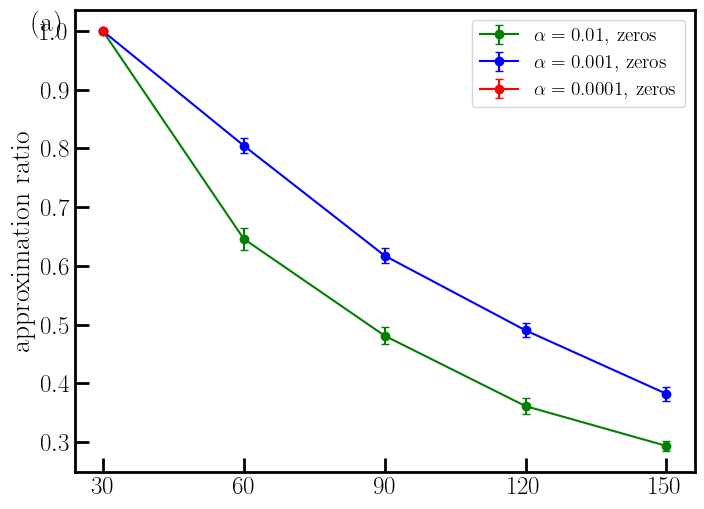

In [2]:
N_list = [30, 60, 90, 120, 150]
#N_list = [150]
R = 100
graph_density = 0
layer = 1
tau = 0.3
# if_adsorting_list = [ "True", "False"]
# if_adsorting_labels = [ "Sorted", "Unsorted"]
method = 'matrix_product_state'
bond = 100
alpha_list = [0.01, 0.001, 0.0001]
# if_analytic_list = [1]
tolerance = 0.0001 ## tolerance of approximation ratio

line_style_list = ["-", "--", "-."]
color_list = ["green", "blue", "red"]
marker_list = ["o", "s", "v", "^", "D", "P", "X"]

ansatz_type = 'linear_cnot' 
initialization_list = ['zeros']

color_list = ["green", "blue", "red"]
# fig = plt.figure(figsize=(8, 12))
fig = plt.figure(figsize=(8, 6))

rc("text", usetex=True)
rc("font", family="serif", weight="bold", size="20")
rc("xtick", labelsize=18)   # x-axis numbers font size
rc("ytick", labelsize=18)   # y-axis numbers font size
rc("xtick", direction="in")
rc("ytick", direction="in")
rc("axes", linewidth=2)
rc("xtick.major", size=10)
rc("xtick.major", width=2)
rc("xtick.minor", size=5)
rc("xtick.minor", width=2)
rc("ytick.major", size=10)
rc("ytick.major", width=2)
rc("ytick.minor", size=5)
rc("ytick.minor", width=2)


dir_0 = './data/'
    
ax_ara = fig.add_subplot(1, 1, 1) 
# ax_ara = fig.add_subplot(2, 1, 1)
# ax_ara_step = fig.add_subplot(2, 1, 2)

ara_array = np.zeros((2, len(alpha_list), len(N_list)))
ara_std_array = np.zeros((2, len(alpha_list), len(N_list)))
steps_ara_array = np.zeros((2, len(alpha_list), len(N_list)))

ifsorting_i = 0 

for ifsorting_i, initialization in enumerate(initialization_list):
    for alpha_i, alpha in enumerate(alpha_list):
        shota = round(100 / alpha)
        print("\n alpha = ", alpha)
        shots = round(100 / alpha)
        for N_i, N in enumerate(N_list):
            r_list = []
            ara_list = []

            # step_list = []
            for r in range(R):
                filename = dir_0 + f"data_shots_{shots}_layer_{layer}/alpha_{alpha}/N_{N}/r_{r}/ansatz_type_{ansatz_type}/initialization_{initialization}/result_random_tau_{tau}.txt"
                # filename = dir_0 + f"{int(graph_density * 100):03}/N_{N}/method_{method}/shots_{shots}/layer_{layer}/alpha_{alpha}/r_{r}/ifadsorting_{if_adsorting}_tau_{tau}_bond_{bond}.pkl"
                if os.path.exists(filename):
                    try:
                        data = np.loadtxt(filename)

                        result_cvar = data[: , 0]
                        result_ara = data[: , 1]
                        result_posseval = data[: , 2]
                        result_stdeval = data[: , 3]

                        index = np.argmin(result_cvar)
                        ara = result_ara[index]

                        # print("best ara", ara)
                        # print(f"Successfully loaded, shape: {data.shape}")
                        # Process data...
                    except Exception as e:
                        print(f"Error loading file: {e}")
                        # Try to see what's in the file
                        try:
                            with open(filename, 'r') as f:
                                first_line = f.readline()
                                print(f"First line: {first_line[:100]}...")
                        except:
                            print("Cannot even read as text file")
                else:
                    # print(f"File does NOT exist")
                    continue

                # print(data.shape)

                r_list.append(r)
                ara_list.append(ara)

                ara_array[ifsorting_i, alpha_i, N_i] += ara

            print("N = ", N, ", len(r_list) = ", len(r_list))
            ara_array[ifsorting_i, alpha_i, N_i] /= len(r_list)
            ara_std_array[ifsorting_i, alpha_i, N_i] = 1.96 * np.std( ara_list ) / np.sqrt(len(r_list))
            

            steps_ara_array[ifsorting_i, alpha_i, N_i] /= len(r_list)
                    
        x_list = [N for N in N_list]
        # ax_ara.plot(x_list, ara_array[ifsorting_i, alpha_i], marker = marker_list[alpha_i], linestyle = line_style_list[ifsorting_i], color = color_list[alpha_i])
        # ax_ara.fill_between(x_list, ara_array[ifsorting_i, alpha_i] - ara_std_array[ifsorting_i, alpha_i], ara_array[ifsorting_i, alpha_i] + ara_std_array[ifsorting_i, alpha_i], alpha=0.3-0.2*if_analytic_i, color=color_list[alpha_i])
        ax_ara.errorbar(x_list, y = ara_array[ifsorting_i, alpha_i], yerr=ara_std_array[ifsorting_i, alpha_i], marker = marker_list[ifsorting_i], linestyle = line_style_list[ifsorting_i], color = color_list[alpha_i],
                        label= r"$\alpha = " + f"{alpha}$, "+ f'{initialization}', capsize=3, alpha = 1-0.5*ifsorting_i)

        # ax_ara_step.plot(x_list, steps_ara_array[ifsorting_i, alpha_i], marker = marker_list[alpha_i], linestyle = line_style_list[ifsorting_i], color = color_list[alpha_i], label= f'{initialization}' + r", $\alpha = " + f"{alpha}$")


# ax_ara.set_xlabel("N")
ax_ara.set_ylabel("approximation ratio")
ax_ara.set_xticks(N_list)
ax_ara.text(15, 1.001, "(a)")
ax_ara.legend(fontsize = 14)

# ax_ara_step.legend(fontsize = 14)
# ax_ara_step.set_xlabel("N")
# ax_ara_step.set_ylabel("iterations")
# ax_ara_step.text(15, 6.3, "(b)")
# ax_ara_step.set_xticks(N_list)

plt.savefig('./largesize_linearcnot.pdf')
plt.show()



 alpha =  0.01
N =  30 , len(r_list) =  1
N =  60 , len(r_list) =  99
N =  90 , len(r_list) =  99
N =  120 , len(r_list) =  53
N =  150 , len(r_list) =  2

 alpha =  0.001
N =  30 , len(r_list) =  1
N =  60 , len(r_list) =  1
N =  90 , len(r_list) =  0
N =  120 , len(r_list) =  0
N =  150 , len(r_list) =  0

 alpha =  0.0001
N =  30 , len(r_list) =  1
N =  60 , len(r_list) =  0


C:\Users\tuccia\AppData\Local\Temp\ipykernel_29516\3192173805.py:104: RuntimeWarning: invalid value encountered in scalar divide
  ara_array[ifsorting_i, alpha_i, N_i] /= len(r_list)
C:\Users\tuccia\AppData\Local\Temp\ipykernel_29516\3192173805.py:108: RuntimeWarning: invalid value encountered in scalar divide
  steps_ara_array[ifsorting_i, alpha_i, N_i] /= len(r_list)


N =  90 , len(r_list) =  0
N =  120 , len(r_list) =  0
N =  150 , len(r_list) =  0


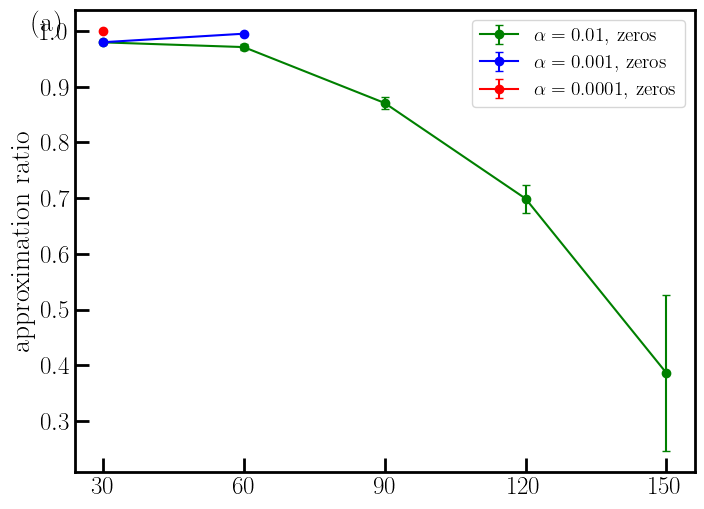

In [3]:
N_list = [30, 60, 90, 120, 150]
#N_list = [150]
R = 100
graph_density = 0
layer = 1
tau = 0.3
# if_adsorting_list = [ "True", "False"]
# if_adsorting_labels = [ "Sorted", "Unsorted"]
method = 'matrix_product_state'
bond = 100
alpha_list = [0.01, 0.001, 0.0001]
# if_analytic_list = [1]
tolerance = 0.0001 ## tolerance of approximation ratio

line_style_list = ["-", "--", "-."]
color_list = ["green", "blue", "red"]
marker_list = ["o", "s", "v", "^", "D", "P", "X"]

ansatz_type = 'structure_like_qubo_YZ_2' 
initialization_list = ['zeros']

color_list = ["green", "blue", "red"]
# fig = plt.figure(figsize=(8, 12))
fig = plt.figure(figsize=(8, 6))

rc("text", usetex=True)
rc("font", family="serif", weight="bold", size="20")
rc("xtick", labelsize=18)   # x-axis numbers font size
rc("ytick", labelsize=18)   # y-axis numbers font size
rc("xtick", direction="in")
rc("ytick", direction="in")
rc("axes", linewidth=2)
rc("xtick.major", size=10)
rc("xtick.major", width=2)
rc("xtick.minor", size=5)
rc("xtick.minor", width=2)
rc("ytick.major", size=10)
rc("ytick.major", width=2)
rc("ytick.minor", size=5)
rc("ytick.minor", width=2)


dir_0 = './data/'
    
ax_ara = fig.add_subplot(1, 1, 1) 
# ax_ara = fig.add_subplot(2, 1, 1)
# ax_ara_step = fig.add_subplot(2, 1, 2)

ara_array = np.zeros((2, len(alpha_list), len(N_list)))
ara_std_array = np.zeros((2, len(alpha_list), len(N_list)))
steps_ara_array = np.zeros((2, len(alpha_list), len(N_list)))

ifsorting_i = 0 

for ifsorting_i, initialization in enumerate(initialization_list):
    for alpha_i, alpha in enumerate(alpha_list):
        shota = round(100 / alpha)
        print("\n alpha = ", alpha)
        shots = round(100 / alpha)
        for N_i, N in enumerate(N_list):
            r_list = []
            ara_list = []

            # step_list = []
            for r in range(R):
                filename = dir_0 + f"data_shots_{shots}_layer_{layer}/alpha_{alpha}/N_{N}/r_{r}/ansatz_type_{ansatz_type}/initialization_{initialization}/result_random_tau_{tau}.txt"
                # filename = dir_0 + f"{int(graph_density * 100):03}/N_{N}/method_{method}/shots_{shots}/layer_{layer}/alpha_{alpha}/r_{r}/ifadsorting_{if_adsorting}_tau_{tau}_bond_{bond}.pkl"
                if os.path.exists(filename):
                    try:
                        data = np.loadtxt(filename)

                        result_cvar = data[: , 0]
                        result_ara = data[: , 1]
                        result_posseval = data[: , 2]
                        result_stdeval = data[: , 3]

                        index = np.argmin(result_cvar)
                        ara = result_ara[index]

                        # print("best ara", ara)
                        # print(f"Successfully loaded, shape: {data.shape}")
                        # Process data...
                    except Exception as e:
                        print(f"Error loading file: {e}")
                        # Try to see what's in the file
                        try:
                            with open(filename, 'r') as f:
                                first_line = f.readline()
                                print(f"First line: {first_line[:100]}...")
                        except:
                            print("Cannot even read as text file")
                else:
                    # print(f"File does NOT exist")
                    continue

                # print(data.shape)

                r_list.append(r)
                ara_list.append(ara)

                ara_array[ifsorting_i, alpha_i, N_i] += ara

            print("N = ", N, ", len(r_list) = ", len(r_list))
            ara_array[ifsorting_i, alpha_i, N_i] /= len(r_list)
            ara_std_array[ifsorting_i, alpha_i, N_i] = 1.96 * np.std( ara_list ) / np.sqrt(len(r_list))
            

            steps_ara_array[ifsorting_i, alpha_i, N_i] /= len(r_list)
                    
        x_list = [N for N in N_list]
        # ax_ara.plot(x_list, ara_array[ifsorting_i, alpha_i], marker = marker_list[alpha_i], linestyle = line_style_list[ifsorting_i], color = color_list[alpha_i])
        # ax_ara.fill_between(x_list, ara_array[ifsorting_i, alpha_i] - ara_std_array[ifsorting_i, alpha_i], ara_array[ifsorting_i, alpha_i] + ara_std_array[ifsorting_i, alpha_i], alpha=0.3-0.2*if_analytic_i, color=color_list[alpha_i])
        ax_ara.errorbar(x_list, y = ara_array[ifsorting_i, alpha_i], yerr=ara_std_array[ifsorting_i, alpha_i], marker = marker_list[ifsorting_i], linestyle = line_style_list[ifsorting_i], color = color_list[alpha_i],
                        label= r"$\alpha = " + f"{alpha}$, "+ f'{initialization}', capsize=3, alpha = 1-0.5*ifsorting_i)

        # ax_ara_step.plot(x_list, steps_ara_array[ifsorting_i, alpha_i], marker = marker_list[alpha_i], linestyle = line_style_list[ifsorting_i], color = color_list[alpha_i], label= f'{initialization}' + r", $\alpha = " + f"{alpha}$")


# ax_ara.set_xlabel("N")
ax_ara.set_ylabel("approximation ratio")
ax_ara.set_xticks(N_list)
ax_ara.text(15, 1.001, "(a)")
ax_ara.legend(fontsize = 14)

# ax_ara_step.legend(fontsize = 14)
# ax_ara_step.set_xlabel("N")
# ax_ara_step.set_ylabel("iterations")
# ax_ara_step.text(15, 6.3, "(b)")
# ax_ara_step.set_xticks(N_list)

plt.savefig('./largesize_ansatzlikequbo.pdf')
plt.show()


 alpha =  0.01
N =  30 , len(r_list) =  1
N =  60 , len(r_list) =  7
N =  90 , len(r_list) =  0
N =  120 , len(r_list) =  0
N =  150 , len(r_list) =  0

 alpha =  0.001
N =  30 , len(r_list) =  0
N =  60 , len(r_list) =  0
N =  90 , len(r_list) =  0
N =  120 , len(r_list) =  0
N =  150 , len(r_list) =  0

 alpha =  0.0001
N =  30 , len(r_list) =  0
N =  60 , len(r_list) =  0
N =  90 , len(r_list) =  0
N =  120 , len(r_list) =  0
N =  150 , len(r_list) =  0


C:\Users\tuccia\AppData\Local\Temp\ipykernel_29516\1001126174.py:104: RuntimeWarning: invalid value encountered in scalar divide
  ara_array[ifsorting_i, alpha_i, N_i] /= len(r_list)
C:\Users\tuccia\AppData\Local\Temp\ipykernel_29516\1001126174.py:108: RuntimeWarning: invalid value encountered in scalar divide
  steps_ara_array[ifsorting_i, alpha_i, N_i] /= len(r_list)


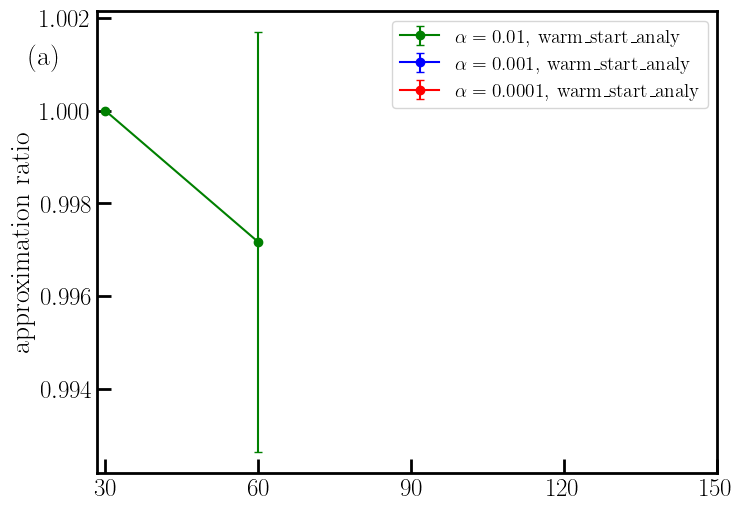

In [4]:
N_list = [30, 60, 90, 120, 150]
#N_list = [150]
R = 100
graph_density = 0
layer = 1
tau = 0.3
# if_adsorting_list = [ "True", "False"]
# if_adsorting_labels = [ "Sorted", "Unsorted"]
method = 'matrix_product_state'
bond = 100
alpha_list = [0.01, 0.001, 0.0001]
# if_analytic_list = [1]
tolerance = 0.0001 ## tolerance of approximation ratio

line_style_list = ["-", "--", "-."]
color_list = ["green", "blue", "red"]
marker_list = ["o", "s", "v", "^", "D", "P", "X"]

ansatz_type = 'structure_like_qubo_YZ_2' 
initialization_list = ['warm_start_analy']

color_list = ["green", "blue", "red"]
# fig = plt.figure(figsize=(8, 12))
fig = plt.figure(figsize=(8, 6))

rc("text", usetex=True)
rc("font", family="serif", weight="bold", size="20")
rc("xtick", labelsize=18)   # x-axis numbers font size
rc("ytick", labelsize=18)   # y-axis numbers font size
rc("xtick", direction="in")
rc("ytick", direction="in")
rc("axes", linewidth=2)
rc("xtick.major", size=10)
rc("xtick.major", width=2)
rc("xtick.minor", size=5)
rc("xtick.minor", width=2)
rc("ytick.major", size=10)
rc("ytick.major", width=2)
rc("ytick.minor", size=5)
rc("ytick.minor", width=2)


dir_0 = './data/'
    
ax_ara = fig.add_subplot(1, 1, 1) 
# ax_ara = fig.add_subplot(2, 1, 1)
# ax_ara_step = fig.add_subplot(2, 1, 2)

ara_array = np.zeros((2, len(alpha_list), len(N_list)))
ara_std_array = np.zeros((2, len(alpha_list), len(N_list)))
steps_ara_array = np.zeros((2, len(alpha_list), len(N_list)))

ifsorting_i = 0 

for ifsorting_i, initialization in enumerate(initialization_list):
    for alpha_i, alpha in enumerate(alpha_list):
        shota = round(100 / alpha)
        print("\n alpha = ", alpha)
        shots = round(100 / alpha)
        for N_i, N in enumerate(N_list):
            r_list = []
            ara_list = []

            # step_list = []
            for r in range(R):
                filename = dir_0 + f"data_shots_{shots}_layer_{layer}/alpha_{alpha}/N_{N}/r_{r}/ansatz_type_{ansatz_type}/initialization_{initialization}/result_random_tau_{tau}.txt"
                # filename = dir_0 + f"{int(graph_density * 100):03}/N_{N}/method_{method}/shots_{shots}/layer_{layer}/alpha_{alpha}/r_{r}/ifadsorting_{if_adsorting}_tau_{tau}_bond_{bond}.pkl"
                if os.path.exists(filename):
                    try:
                        data = np.loadtxt(filename)

                        result_cvar = data[: , 0]
                        result_ara = data[: , 1]
                        result_posseval = data[: , 2]
                        result_stdeval = data[: , 3]

                        index = np.argmin(result_cvar)
                        ara = result_ara[index]

                        # print("best ara", ara)
                        # print(f"Successfully loaded, shape: {data.shape}")
                        # Process data...
                    except Exception as e:
                        print(f"Error loading file: {e}")
                        # Try to see what's in the file
                        try:
                            with open(filename, 'r') as f:
                                first_line = f.readline()
                                print(f"First line: {first_line[:100]}...")
                        except:
                            print("Cannot even read as text file")
                else:
                    # print(f"File does NOT exist")
                    continue

                # print(data.shape)

                r_list.append(r)
                ara_list.append(ara)

                ara_array[ifsorting_i, alpha_i, N_i] += ara

            print("N = ", N, ", len(r_list) = ", len(r_list))
            ara_array[ifsorting_i, alpha_i, N_i] /= len(r_list)
            ara_std_array[ifsorting_i, alpha_i, N_i] = 1.96 * np.std( ara_list ) / np.sqrt(len(r_list))
            

            steps_ara_array[ifsorting_i, alpha_i, N_i] /= len(r_list)
                    
        x_list = [N for N in N_list]
        # ax_ara.plot(x_list, ara_array[ifsorting_i, alpha_i], marker = marker_list[alpha_i], linestyle = line_style_list[ifsorting_i], color = color_list[alpha_i])
        # ax_ara.fill_between(x_list, ara_array[ifsorting_i, alpha_i] - ara_std_array[ifsorting_i, alpha_i], ara_array[ifsorting_i, alpha_i] + ara_std_array[ifsorting_i, alpha_i], alpha=0.3-0.2*if_analytic_i, color=color_list[alpha_i])
        ax_ara.errorbar(x_list, y = ara_array[ifsorting_i, alpha_i], yerr=ara_std_array[ifsorting_i, alpha_i], marker = marker_list[ifsorting_i], linestyle = line_style_list[ifsorting_i], color = color_list[alpha_i],
                        label= r"$\alpha = " + f"{alpha}$, "+ f'{initialization}', capsize=3, alpha = 1-0.5*ifsorting_i)

        # ax_ara_step.plot(x_list, steps_ara_array[ifsorting_i, alpha_i], marker = marker_list[alpha_i], linestyle = line_style_list[ifsorting_i], color = color_list[alpha_i], label= f'{initialization}' + r", $\alpha = " + f"{alpha}$")


# ax_ara.set_xlabel("N")
ax_ara.set_ylabel("approximation ratio")
ax_ara.set_xticks(N_list)
ax_ara.text(15, 1.001, "(a)")
ax_ara.legend(fontsize = 14)

# ax_ara_step.legend(fontsize = 14)
# ax_ara_step.set_xlabel("N")
# ax_ara_step.set_ylabel("iterations")
# ax_ara_step.text(15, 6.3, "(b)")
# ax_ara_step.set_xticks(N_list)

plt.savefig('./largesize_ansatzlikequbo_warm.pdf')
plt.show()